# Module 3 Demos: Speech Feature Extraction
This Colab notebook demonstrates:
- Pitch extraction (YIN)
- Formant estimation (LPC)
- MFCC computation and visualization
- Zero-crossing rate analysis
- Speaker embeddings with SpeechBrain

Run each cell sequentially to see the outputs and listen to audio.

In [2]:
# Perforn the pip install process for installing libraries
!pip install -q librosa numpy matplotlib speechbrain transformers soundfile

In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

## 1. Load a Sample Audio

In [ ]:
# Load a sample audio clip
y, sr = librosa.load(librosa.ex('trumpet'), sr=16000)
print(f'Sample rate: {sr} Hz, Duration: {len(y)/sr:.2f} s')
display(Audio(y, rate=sr))

Sample rate: 16000 Hz, Duration: 5.33 s


## 2. Pitch Extraction with YIN

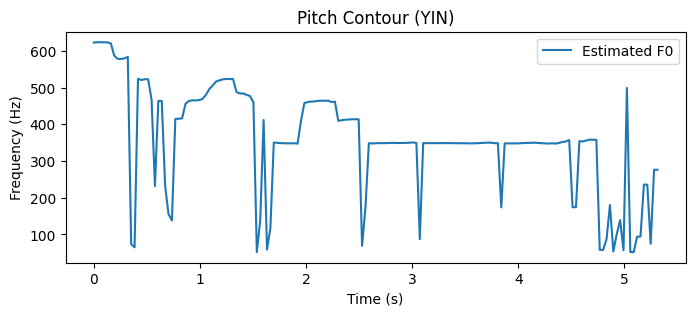

In [ ]:
# Estimate pitch (F0) using librosa.yin
f0 = librosa.yin(y, fmin=50, fmax=1000, sr=sr)
times = librosa.times_like(f0, sr=sr)

plt.figure(figsize=(8,3))
plt.plot(times, f0, label='Estimated F0')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Contour (YIN)')
plt.legend()
plt.show()

## 3. Formant Estimation via LPC

In [ ]:
# LPC-based formant estimation
import numpy as np

# Take a short frame for a vowel-like steady segment
frame = y[4000:4000+1024] * np.hamming(1024)
order = 14
lpc_coeffs = librosa.lpc(frame, order=order)
roots = np.roots(lpc_coeffs)
roots = [r for r in roots if np.imag(r) >= 0]
ang = np.angle(roots)
formants = sorted(ang * sr / (2*np.pi))
print('Estimated formant frequencies (Hz):', formants[:3])

Estimated formant frequencies (Hz): [np.float64(782.1058311287081), np.float64(1324.05247309407), np.float64(2190.3326233669504)]


## 4. MFCC Computation and Visualization

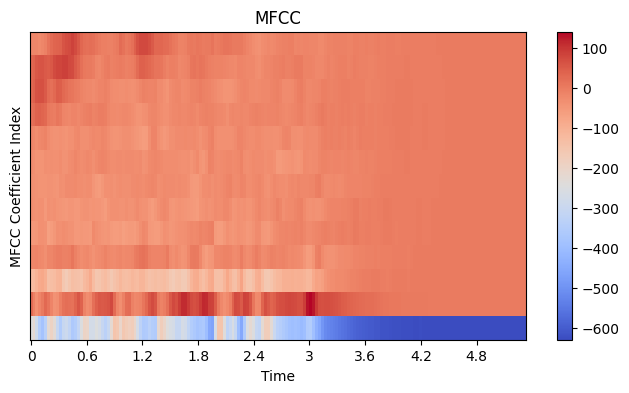

In [ ]:
# Compute MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(8,4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar()
plt.title('MFCC')
plt.ylabel('MFCC Coefficient Index')
plt.show()

## 5. Zero-Crossing Rate Analysis

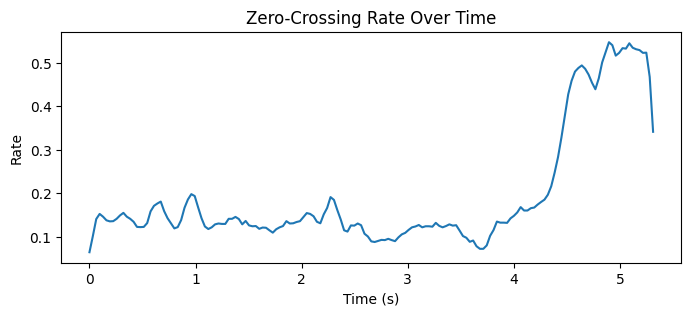

In [ ]:
# Compute zero-crossing rate
zcr = librosa.feature.zero_crossing_rate(y)
times = librosa.times_like(zcr[0], sr=sr)

plt.figure(figsize=(8,3))
plt.plot(times, zcr[0], label='Zero-Crossing Rate')
plt.xlabel('Time (s)')
plt.ylabel('Rate')
plt.title('Zero-Crossing Rate Over Time')
plt.show()

## 6. Speaker Embeddings with SpeechBrain

In [ ]:
# Download a pretrained speaker embedding model
from speechbrain.pretrained import EncoderClassifier
import torch # Import torch
#Pull in SpeechBrain’s pre-trained ECAPA-TDNN speaker-recognition model and tell it where to save its files.
classifier = EncoderClassifier.from_hparams(source='speechbrain/spkrec-ecapa-voxceleb',
                                           savedir='pretrained_models/spkrec-ecapa-voxceleb')

# Extract embedding
# Convert numpy array to torch tensor and add batch dimension
audio_tensor = torch.from_numpy(y).unsqueeze(0)
#Feed that tensor into encode_batch(), and the model returns a fixed-length vector that captures the unique characteristics of the speaker’s voice.
embedding = classifier.encode_batch(audio_tensor)
print('Embedding shape:', embedding.shape)
#You’ll get something like a [1×1×192] tensor—one embedding of 192 numbers—which you can then use for voice comparison, clustering, or authentication.

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in pretrained_models/spkrec-ecapa-voxceleb.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /content/pretrained_models/spkrec-ecapa-voxceleb/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/content/pretrained_models/spkrec-ecapa-voxceleb/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /content/pretraine

Embedding shape: torch.Size([1, 1, 192])


## You can try to extract speaker embeddings from human voice and how it is different from a musical instrument that we have used in this lab.